<a href="https://colab.research.google.com/github/MuhammadRhakan/econometrics-property-sectors/blob/main/Econometric_End_to_End.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Econometric Analysis on Capital Structure Determinants

## Case Study: The Indonesian Property Sector (2019-2023)

### Executive Summary
This study aims to identify the financial factors that influence the `debt-to-equity ratios` (DER) of property companies listed on the Indonesia Stock Exchange. By analyzing variables such as `Net Profit Margin` (NPM), `Current Ratio` (CR), `Non-Debt Tax Shields` (NDTS), and `Firm Size` (FS), we employ panel data regression techniques to determine corporate behavior in this sector.

### Prerequisites

In this section, we load the necessary Python libraries for data manipulation (`pandas`, `numpy`) and visualization (`seaborn`, `matplotlib`). The dataset is sourced from the financial statements of 17 property companies over a 5-year period.

**Variable Definitions:**
* **DER (Dependent Variable):** Debt to Equity Ratio, representing capital structure.
* **NPM:** Net Profit Margin (Profitability).
* **CR:** Current Ratio (Liquidity).
* **NDTS:** Non-Debt Tax Shield (Depreciation/Total Assets).
* **FS:** Firm Size (Log of Total Assets).

In [1]:
!pip install linearmodels

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel('finance.xlsx')

In [4]:
df.head()

,CODE,YEAR,NPM,CR,NDTS,DER,FS
0,AMAN,2019,0.124327,2.458075,0.033186,0.416831,20.405978
1,BCIP,2019,0.176983,1.383613,0.001104,0.999990,27.488380
2,BSDE,2019,0.441798,3.927680,0.021129,0.622017,31.629973
3,CTRA,2019,0.168670,2.174197,0.038556,1.037884,17.404460
4,DMAS,2019,0.503884,3.711244,0.012431,0.172610,29.661400


In [5]:
df[['NPM', 'CR', 'NDTS', 'FS', 'DER']].describe().T

,count,mean,std,min,25%,50%,75%,max
NPM,85.0,0.261149,0.187052,0.002056,0.125486,0.207472,0.359488,0.988249
CR,85.0,2.622878,1.410744,0.874717,1.383613,2.423235,3.206512,6.543888
NDTS,85.0,0.031792,0.029355,0.000181,0.008313,0.029123,0.042950,0.141819
FS,85.0,25.935129,4.442801,15.595953,23.939038,27.511193,29.050569,31.833138
DER,85.0,0.701236,0.446899,0.085656,0.391691,0.586390,1.003659,1.954854


The descriptive statistics provide a high-level overview of the financial health of the sector:
* **Profitability (NPM):** The average margin is approximately 26.1%, though significant volatility exists (min 0.2% to max 98.8%).
* **Capital Structure (DER):** The average DER is 0.701, suggesting that, on average, firms in this sector maintain more equity than debt, though some firms approach a ratio of 1.95.
* **Liquidity (CR):** An average current ratio of 2.62 indicates a generally strong ability to cover short-term obligations.

### Exploratory Data Analysis
To understand the distribution and potential outliers within our variables, we generate boxplots categorized by year. This allows us to observe how the COVID-19 pandemic (circa 2020-2021) and subsequent recovery impacted the financial metrics of the property industry.

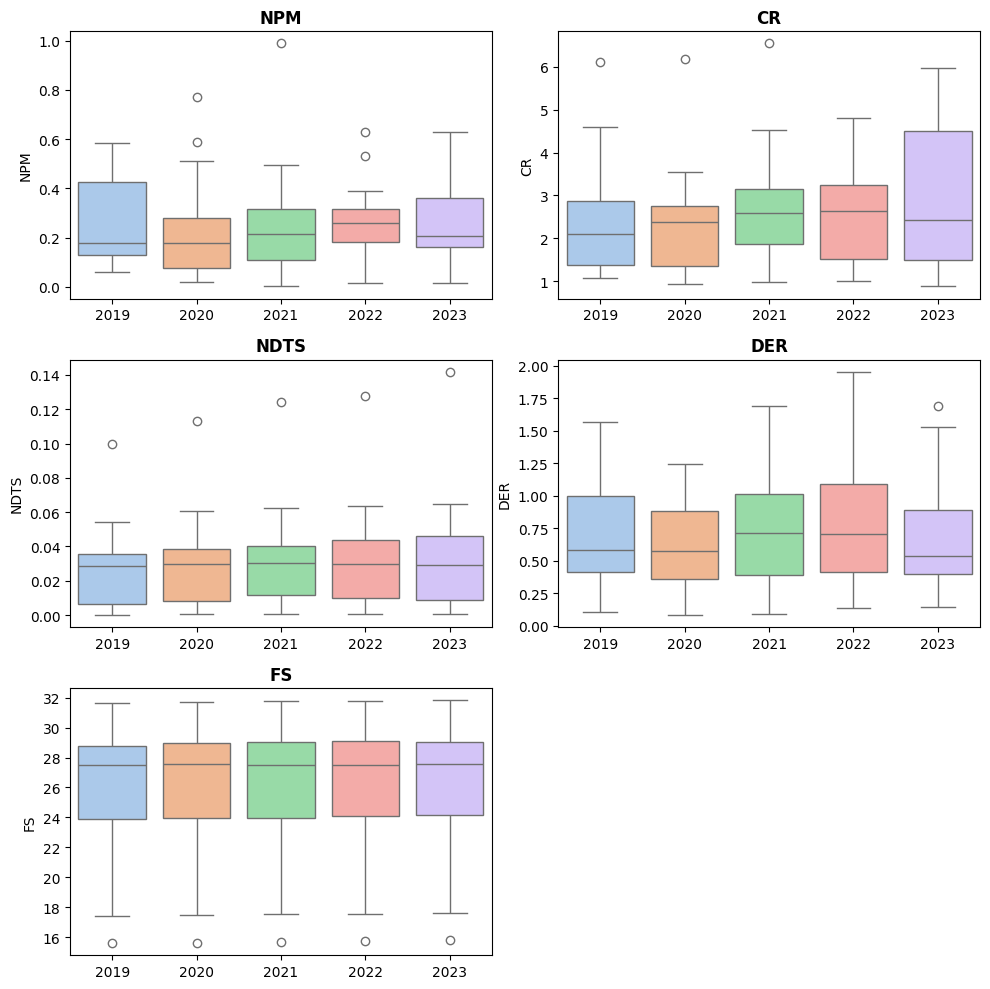

In [6]:
def boxplots(data):
    fig, ax = plt.subplots(
        nrows = 3,
        ncols = 2,
        figsize = (10, 10))
    axs = ax.flatten()

    for i, col in enumerate(data.columns[2:]):
        sns.boxplot(data=df,
                    x='YEAR',
                    y=col,
                    palette="pastel",
                    hue='YEAR', legend=False,
                    ax=axs[i])
        axs[i].set_title(col, fontweight='bold')
        axs[i].set_xlabel('')

    for j in range(5, 6):           # Remove empty chart on grid
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()


# Calling function
boxplots(df)

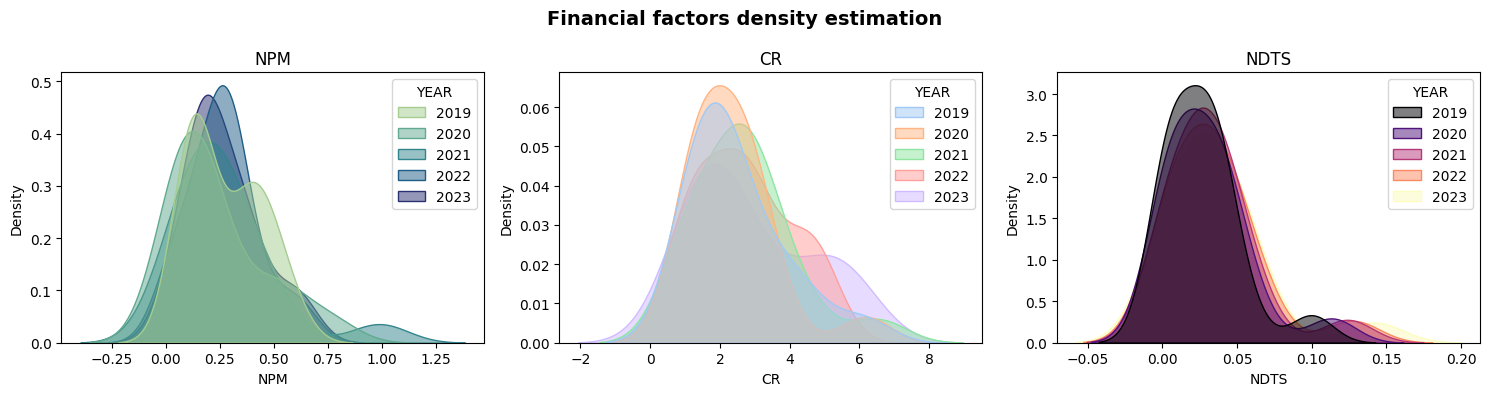

In [7]:
def density_plots(data):
    variables = ['NPM', 'CR', 'NDTS']
    palettes = ['crest', 'pastel', 'magma']

    fig, ax = plt.subplots(
        nrows = 1,
        ncols = len(variables),
        figsize = (len(variables) * 5, 4))
    fig.suptitle('Financial factors density estimation', fontweight='bold', fontsize=14)
    axs = ax.flatten()

    for i, col in enumerate(variables):
        sns.kdeplot(data=data,
                    x=col,
                    hue='YEAR',
                    ax=axs[i],
                    palette=palettes[i],
                    fill=True,
                    alpha=0.5,
        )
        axs[i].set_title(col)

    plt.tight_layout()
    plt.show()


# Calling function
density_plots(df)

In [8]:
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objects as go

def scatterplots_plotly(data, period, features, target):
    # Create consistent color mapping
    unique_periods = sorted(data[period].unique())
    colors = px.colors.qualitative.Safe  # excellent differentiation
    color_map = dict(zip(unique_periods, colors))

    symbols = ['circle', 'square', 'diamond', 'cross', 'x']

    # Create subplots
    fig = make_subplots(
        rows=1, cols=len(features),
        subplot_titles=features
    )

    for i, var in enumerate(features):
        for p in unique_periods:
            df_subset = data[data[period] == p]

            fig.add_trace(
                go.Scatter(
                    x=df_subset[var],
                    y=df_subset[target],
                    mode='markers',
                    name=str(p),
                    marker=dict(
                        color=color_map[p],
                        symbol=symbols[unique_periods.index(p) % len(symbols)],
                        size=8),
                    legendgroup=str(p),   # keeps legend unified
                    showlegend=(i == 0),  # show legend only once
                ),
                row=1, col=i+1
            )

    fig.update_layout(
        title="Variables vs Target",
        height=500,
        width=1500,
    )

    fig.show()


# Calling function
scatterplots_plotly(df, period='YEAR', features=['NPM', 'CR', 'NDTS'], target='DER')

In [9]:
import plotly.graph_objects as go

def heatmap_plotly(data, variables):
    # Precompute pivot tables
    pivots = {
        var: data.pivot(index='CODE', columns='YEAR', values=var)
        for var in variables
    }

    # Create figure
    fig = go.Figure()

    # Add one heatmap per variable (only first visible)
    for i, var in enumerate(variables):
        df_pivot = pivots[var]

        fig.add_trace(
            go.Heatmap(
                z=df_pivot.values,
                x=df_pivot.columns,
                y=df_pivot.index,
                colorscale='RdBu',   # better than mako for centered data
                zmin=-1,
                zmax=1,
                zmid=0,
                colorbar=dict(title=var),
                visible=(i == 0)
            )
        )

    # Dropdown menu
    buttons = []
    for i, var in enumerate(variables):
        visible = [False] * len(variables)
        visible[i] = True

        buttons.append(
            dict(
                label=var,
                method="update",
                args=[
                    {"visible": visible},
                    {"title": f"Heatmap of {var} by Company and Year"}
                ]
            )
        )

    fig.update_layout(
        title=f"{variables[0]} by Company and Year",
        updatemenus=[
            dict(
                buttons=buttons,
                direction="down",
                showactive=True,
                x=1.05,
                y=1
            )
        ],
        height=600,
        width=600
    )

    fig.show()


# Calling function
heatmap_plotly(data=df, variables=['NPM', 'CR', 'NDTS'])

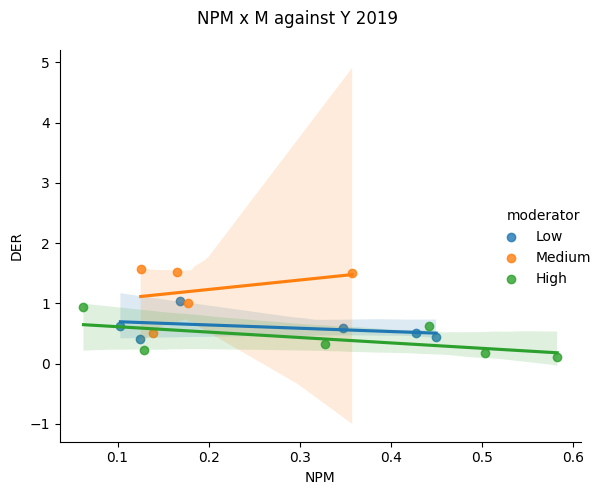

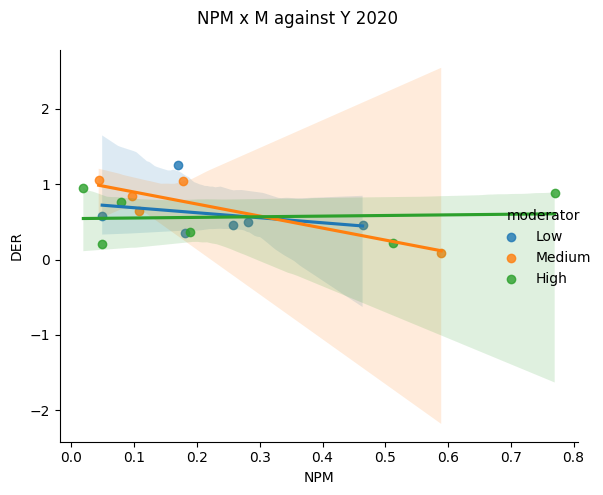

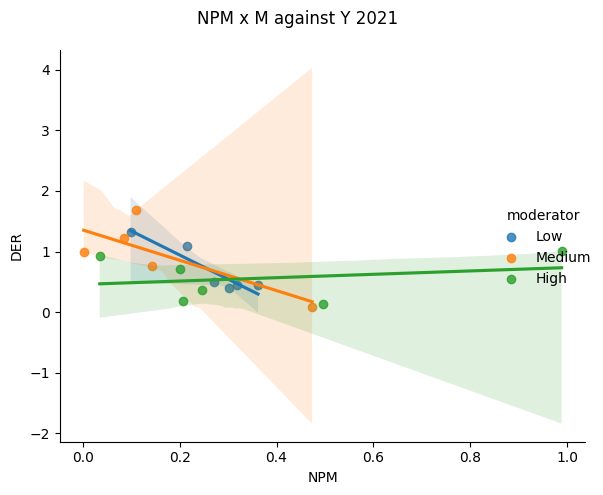

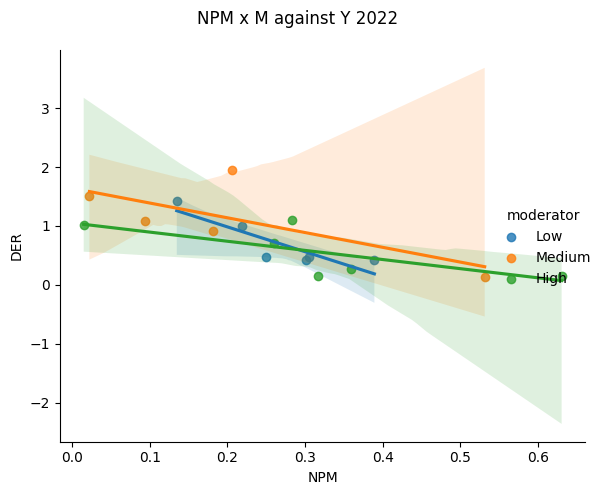

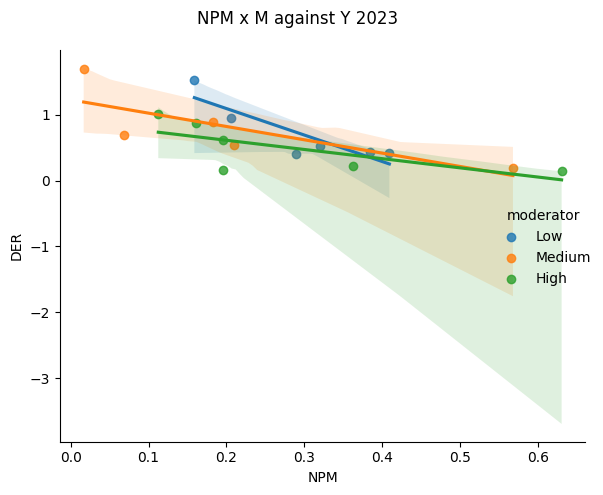

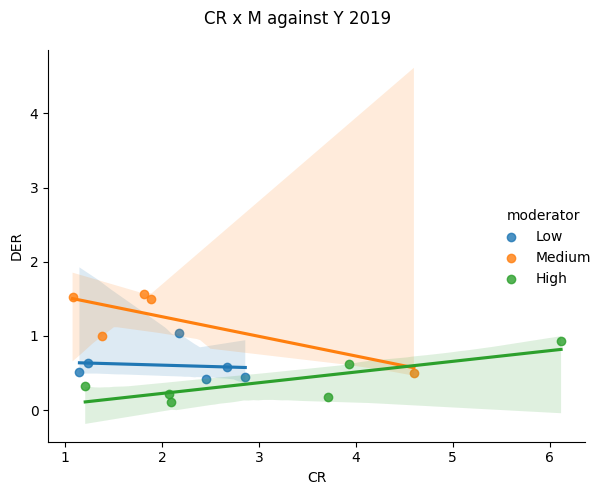

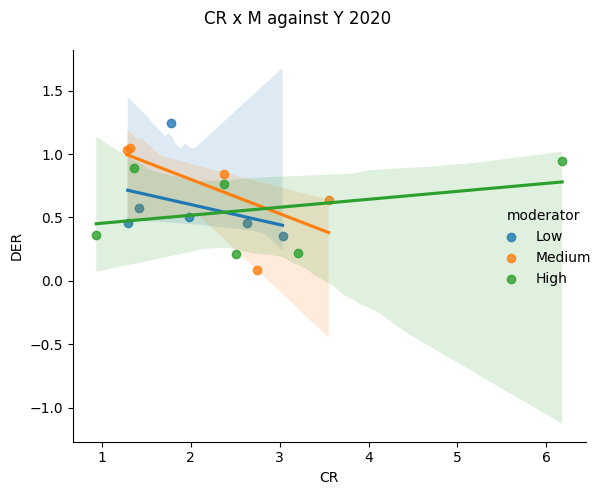

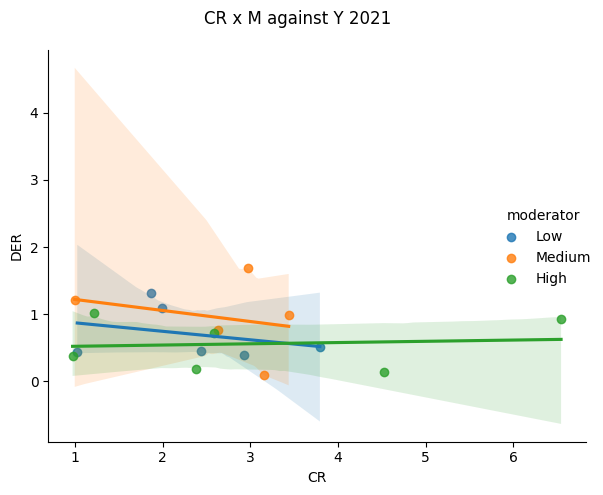

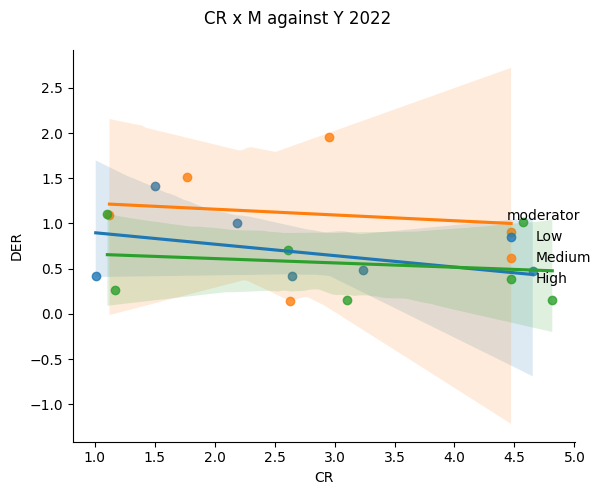

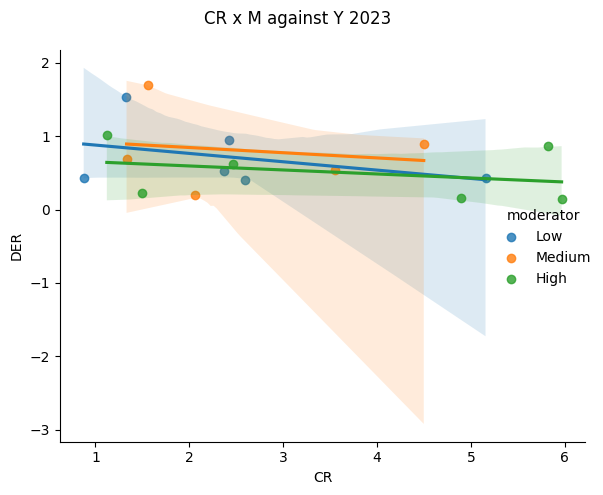

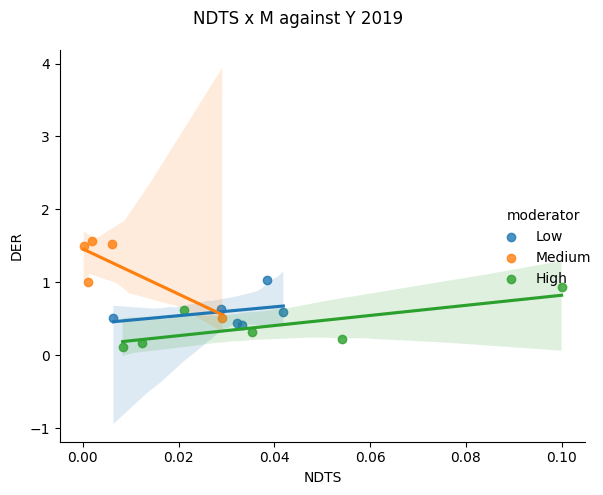

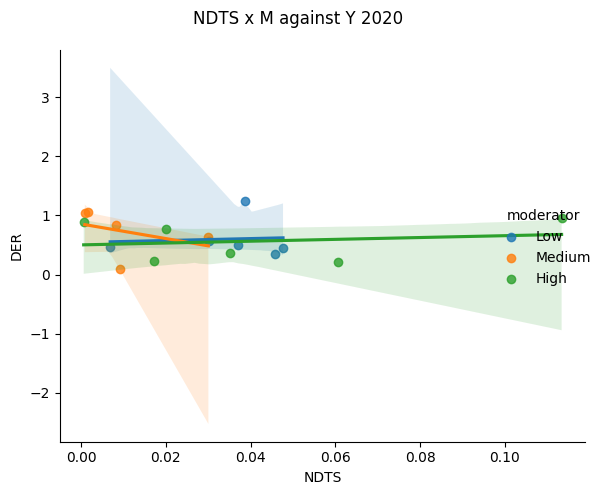

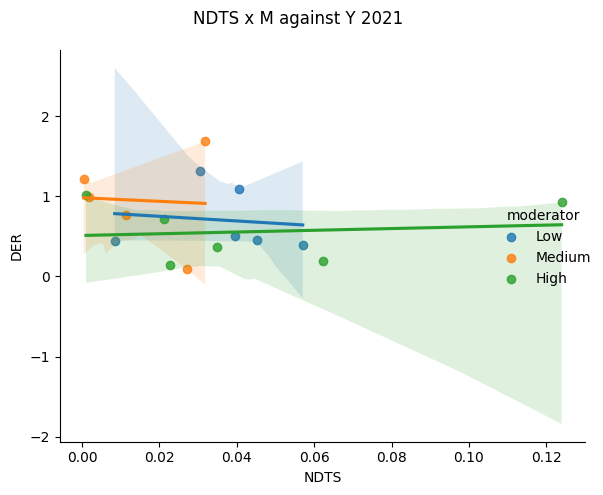

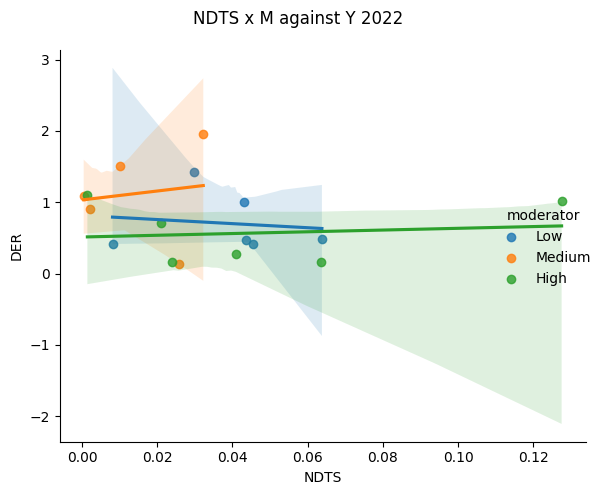

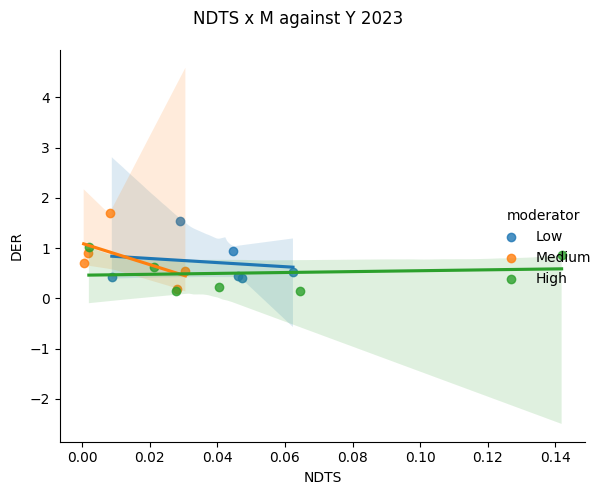

In [10]:
def try_moderation(data, period, variables, moderation, target):
  years = data[period].dropna().unique()

  for var in variables:
    for yr in years:
      df_year = data[data[period] == yr].copy()

      # Check if enough unique values exist for moderator grouping
      if df_year[moderation].nunique() < 3:
        print(f"Skipping {var}MY_{yr}: not enough unique values in moderator '{moderation}'")
        continue

      try:
        # Create moderation group
        df_year['moderator'] = pd.qcut(df_year[moderation], q=3, labels=['Low', 'Medium', 'High'])

        # Plot
        plot = sns.lmplot(data=df_year, x=var, y=target, hue='moderator', height=5, aspect=1)
        plot.fig.suptitle(f'{var} x M against Y {yr}', fontsize=12)
        plot.fig.tight_layout()
        plot.fig.subplots_adjust(top=0.9)  # Adjust for suptitle

        plt.show()
      except Exception as e:
        print(f"Error in {var}MY_{yr}: {e}")


try_moderation(df, period='YEAR', variables= ['NPM', 'CR', 'NDTS'], moderation='FS', target='DER')

## Statistical Analysis

### Data Transformation

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

def data_transformation(data):
    # Transform all numeric values except `YEAR`
    data.iloc[:,2:] = data.iloc[:,2:].apply(lambda x: x - x.mean())
    return data


def prepare_dataset(raw_df: pd.DataFrame):
    # Introduce moderator variables
    raw_df['M_NPM'] = raw_df['FS'] * raw_df['NPM']
    raw_df['M_CR'] = raw_df['FS'] * raw_df['CR']
    raw_df['M_NDTS'] = raw_df['FS'] * raw_df['NDTS']

    # Transform data with mean-centering
    # Call `data_transformation` function
    demeaned_data = data_transformation(raw_df)

    # Perform Z-score standardization for demeaned data
    scaled_values = scaler.fit_transform(demeaned_data.iloc[:,2:])
    scaled_df = raw_df.copy()
    scaled_df.iloc[:,2:] = scaled_values

    return {
        'original': demeaned_data,
        'scaled': scaled_df
    }


dataset = prepare_dataset(df)

### Econometric Modeling

In [12]:
from linearmodels.panel import PanelOLS, compare

def panel_regression(dataset):
    # Set Company and Period as Index
    panel_data = dataset.set_index(['CODE', 'YEAR'])

    # Model Fixed Effect Regression
    formula_fe = 'DER ~ NPM + CR + NDTS + M_NPM + M_CR + M_NDTS + EntityEffects + TimeEffects'
    model_fe = PanelOLS.from_formula(formula = formula_fe, data = panel_data)
    result_fe = model_fe.fit(cov_type="clustered", cluster_entity=True)

    # Model Random Effect Regression
    formula_re = 'DER ~ NPM + CR + NDTS + M_NPM + M_CR + M_NDTS'
    model_re = PanelOLS.from_formula(formula = formula_re, data = panel_data)
    result_re = model_re.fit()

    print(compare({"FE": result_fe, "RE": result_re}))

    return {
        'fixed_effect': result_fe,
        'random_effect': result_re
    }

In [13]:
result_original = panel_regression(dataset['original'])
result_scaled = panel_regression(dataset['scaled'])

                  Model Comparison                  
                                   FE             RE
----------------------------------------------------
Dep. Variable                     DER            DER
Estimator                    PanelOLS       PanelOLS
No. Observations                   85             85
Cov. Est.                   Clustered     Unadjusted
R-squared                      0.0875         0.2961
R-Squared (Within)             0.0632        -0.2377
R-Squared (Between)            0.0537         0.4806
R-Squared (Overall)            0.0561         0.2961
F-statistic                    0.9268         5.5375
P-value (F-stat)               0.4827         0.0001
=====================     ===========   ============
NPM                            2.8125        -1.1460
                             (0.8361)      (-0.5055)
CR                            -0.2767        -0.1534
                            (-0.6369)      (-0.3501)
NDTS                          -6.6520         

In [14]:
result_original['random_effect'].summary

Dep. Variable:,DER,R-squared:,0.2961
Estimator:,PanelOLS,R-squared (Between):,0.4806
No. Observations:,85,R-squared (Within):,-0.2377
Date:,"Thu, Mar 19 2026",R-squared (Overall):,0.2961
Time:,02:51:08,Log-likelihood,-36.726
Cov. Estimator:,Unadjusted,,
,,F-statistic:,5.5375
Entities:,17,P-value,0.0001
Avg Obs:,5.0000,Distribution:,"F(6,79)"
Min Obs:,5.0000,,
Max Obs:,5.0000,F-statistic (robust):,5.5375


In [15]:
result_scaled['random_effect'].summary

Dep. Variable:,DER,R-squared:,0.2961
Estimator:,PanelOLS,R-squared (Between):,0.4806
No. Observations:,85,R-squared (Within):,-0.2377
Date:,"Thu, Mar 19 2026",R-squared (Overall):,0.2961
Time:,02:51:08,Log-likelihood,-105.69
Cov. Estimator:,Unadjusted,,
,,F-statistic:,5.5375
Entities:,17,P-value,0.0001
Avg Obs:,5.0000,Distribution:,"F(6,79)"
Min Obs:,5.0000,,
Max Obs:,5.0000,F-statistic (robust):,5.5375


### Hypothesis Evaluation

In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats
from statsmodels.tools.tools import add_constant


# MAIN FUNCTION
def check_panel_assumptions(X, result, raw_data):
    panel_data = raw_data.set_index(['CODE', 'YEAR'])
    residuals = result.resids
    fitted = result.fitted_values

    # Ensure alignment
    residuals = residuals.squeeze()
    fitted = fitted.squeeze()


    # 1. HETEROSKEDASTICITY
    def heteroskedasticity():
        print("\n=== Heteroskedasticity Check (Panel) ===")

        plt.figure(figsize=(5,5))
        plt.scatter(fitted, residuals)
        plt.axhline(0, linestyle='--')
        plt.title("Residuals vs Fitted")
        plt.xlabel("Fitted")
        plt.ylabel("Residuals")
        plt.tight_layout()
        plt.show()

        # Breusch-Pagan (approximation)
        exog = add_constant(fitted)
        bp_test = het_breuschpagan(residuals, exog)

        labels = ['LM Stat', 'LM p-value', 'F Stat', 'F p-value']
        bp_results = dict(zip(labels, bp_test))

        for k, v in bp_results.items():
            print(f"{k}: {round(v,4)}")

        if bp_results['LM p-value'] < 0.05:
            print("❌ Heteroskedasticity detected (approx)")
        else:
            print("✅ No strong evidence of heteroskedasticity")

        print("👉 In panel models, prefer clustered/robust SE (you already used them)")


    # 2. MULTICOLLINEARITY
    def multicollinearity():
        print("\n=== Multicollinearity Check ===")

        vif_data = pd.DataFrame({
            "Variable": X.columns,
            "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        })

        print(vif_data)

        if vif_data['VIF'].max() > 10:
            print("❌ Multicollinearity detected")
        else:
            print("✅ No multicollinearity issue")


    # 3. AUTOCORRELATION (WOOLDRIDGE)
    def wooldridge_autocorrelation():
        print("\n=== Autocorrelation Check (Wooldridge-style approximation) ===")

        df = panel_data.copy()
        df['resid'] = residuals

        df['resid_lag'] = df.groupby(level=0)['resid'].shift(1)
        df = df.dropna()

        model = PanelOLS.from_formula(
            'resid ~ resid_lag',
            data=df
        )

        res = model.fit()

        coef = res.params['resid_lag']
        pval = res.pvalues['resid_lag']

        print(f"Lag coefficient: {coef:.4f}")
        print(f"p-value: {pval:.4f}")

        if pval < 0.05:
            print("❌ Autocorrelation detected")
        else:
            print("✅ No autocorrelation")


    # 4. NORMALITY
    def normality():
        print("\n=== Normality Check ===")

        plt.figure(figsize=(5,5))
        sns.histplot(residuals, kde=True)
        plt.title("Residual Distribution")
        plt.show()

        plt.figure(figsize=(5,5))
        stats.probplot(residuals, dist='norm', plot=plt)
        plt.title("Q-Q Plot")
        plt.show()

        stat, p = stats.shapiro(residuals)

        print(f"Shapiro-Wilk p-value: {p:.4f}")

        if p < 0.05:
            print("❌ Not normally distributed")
        else:
            print("✅ Residuals approx normal")

        print("👉 Normality is less critical in panel models")


    # 5. CROSS-SECTIONAL DEPENDENCE
    def cross_sectional_dependence():
        print("\n=== Cross-Sectional Dependence (Pesaran CD approximation) ===")

        df = panel_data.copy()
        df['resid'] = residuals

        pivot = df['resid'].unstack(level=0)

        corr_matrix = pivot.corr()

        avg_corr = corr_matrix.values[np.triu_indices_from(corr_matrix, k=1)].mean()

        print(f"Average pairwise correlation: {avg_corr:.4f}")

        if abs(avg_corr) > 0.2:
            print("❌ Possible cross-sectional dependence")
        else:
            print("✅ Weak cross-sectional dependence")


    # CALLING ALL FUNCTIONS
    heteroskedasticity()
    multicollinearity()
    wooldridge_autocorrelation()
    normality()
    cross_sectional_dependence()

In [17]:
X_original = dataset['original'][['NPM', 'CR', 'NDTS', 'M_NPM', 'M_CR', 'M_NDTS']]
X_scaled = dataset['scaled'][['NPM', 'CR', 'NDTS', 'M_NPM', 'M_CR', 'M_NDTS']]


=== Heteroskedasticity Check (Panel) ===


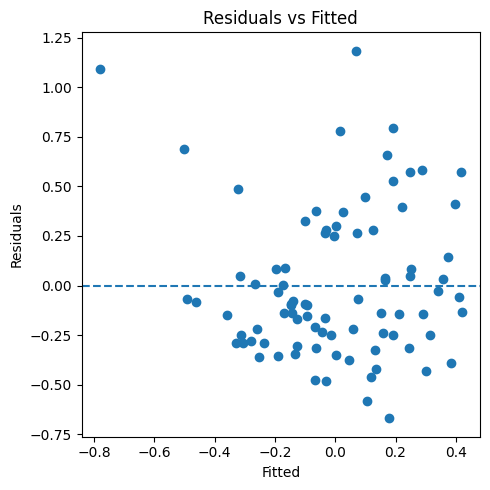

LM Stat: 0.4455
LM p-value: 0.5045
F Stat: 0.4373
F p-value: 0.5103
✅ No strong evidence of heteroskedasticity
👉 In panel models, prefer clustered/robust SE (you already used them)

=== Multicollinearity Check ===
  Variable         VIF
0      NPM  101.041485
1       CR  214.606373
2     NDTS  218.221407
3    M_NPM  109.028491
4     M_CR  258.323900
5   M_NDTS  233.208072
❌ Multicollinearity detected

=== Autocorrelation Check (Wooldridge-style approximation) ===
Lag coefficient: 0.6156
p-value: 0.0000
❌ Autocorrelation detected

=== Normality Check ===


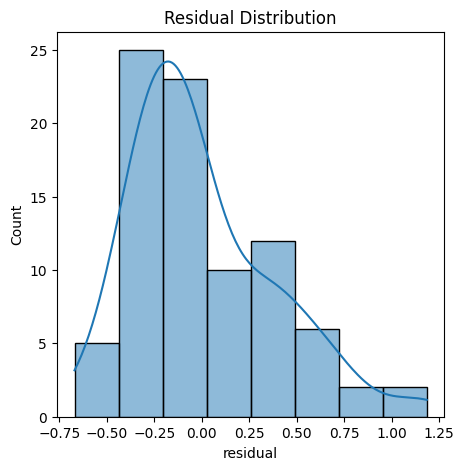

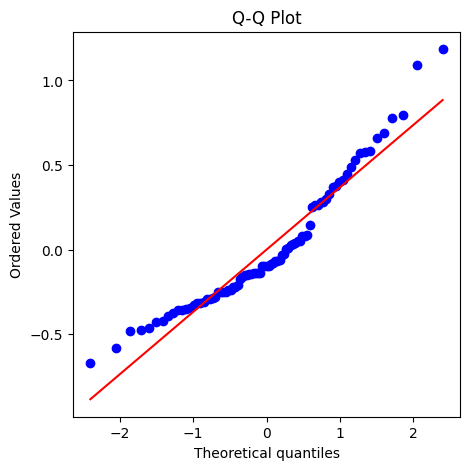

Shapiro-Wilk p-value: 0.0002
❌ Not normally distributed
👉 Normality is less critical in panel models

=== Cross-Sectional Dependence (Pesaran CD approximation) ===
Average pairwise correlation: 0.0405
✅ Weak cross-sectional dependence


In [33]:
check_panel_assumptions(X_original, result_original['random_effect'], dataset['original'])


=== Heteroskedasticity Check (Panel) ===


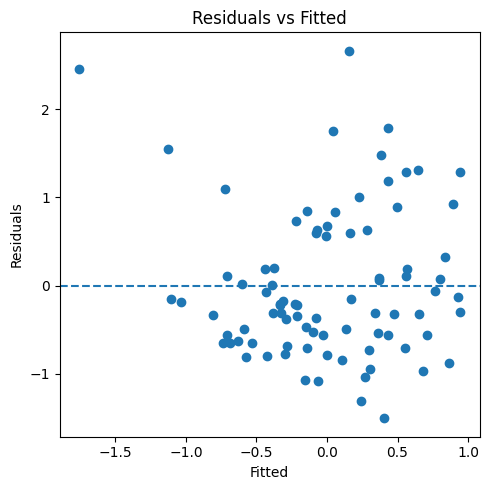

LM Stat: 0.4455
LM p-value: 0.5045
F Stat: 0.4373
F p-value: 0.5103
✅ No strong evidence of heteroskedasticity
👉 In panel models, prefer clustered/robust SE (you already used them)

=== Multicollinearity Check ===
  Variable         VIF
0      NPM  101.041485
1       CR  214.606373
2     NDTS  218.221407
3    M_NPM  109.028491
4     M_CR  258.323900
5   M_NDTS  233.208072
❌ Multicollinearity detected

=== Autocorrelation Check (Wooldridge-style approximation) ===
Lag coefficient: 0.6156
p-value: 0.0000
❌ Autocorrelation detected

=== Normality Check ===


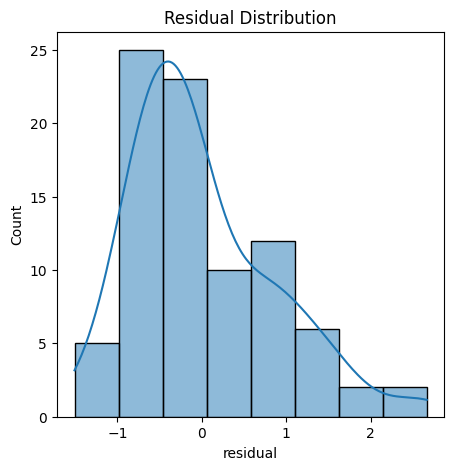

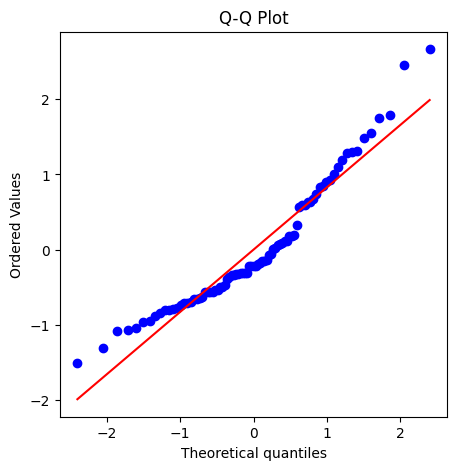

Shapiro-Wilk p-value: 0.0002
❌ Not normally distributed
👉 Normality is less critical in panel models

=== Cross-Sectional Dependence (Pesaran CD approximation) ===
Average pairwise correlation: 0.0405
✅ Weak cross-sectional dependence


In [34]:
check_panel_assumptions(X_scaled, result_scaled['random_effect'], dataset['original'])